# WCPFC BDEP Bycatch Mortality Bias — Notebook 1
## Phase 1: Data Ingestion & Stratum Construction
## Phase 2: Data Quality Diagnostics

---

### Project overview

**Working title:** *Unknown fate, unknown bias: quantifying downward bias in nominal bycatch mortality estimates from WCPFC public-domain observer data*

**Target journal:** Fisheries Research (Q1, Scopus)

**Data source:** WCPFC BDEP workbook (December 2025 release)  
https://www.wcpfc.int/public-domain-bycatch-data-files

---

### What this notebook does and why

This notebook covers the first two analytical phases of the project.

**Phase 1** loads the WCPFC observer data, builds the analysis strata
(fishery × species × year), and derives the four core variables that
every subsequent analysis depends on: C (captures/interactions),
M (observed mortalities), L (observed live releases), and
U = C − M − L (unknown fate).

**Why Phase 1 is justified:**  
The WCPFC BDEP notes explicitly state (Note 5): *'The sum of the
mortalities and live releases will often not equal the captures (i.e.
interactions with the gear) since the observer (for one reason or the
other) may not have recorded the FATE and the CONDITION of every
encounter.'* Our variable U is the arithmetic realisation of this
documented data gap. We are not inventing a problem — we are measuring
one the data provider itself acknowledges.

**Phase 2** runs data quality diagnostics: integrity checks,
unknown-fate burden quantification across strata, and a pre/post-2017
comparison for purse-seine fisheries.

**Why Phase 2 is justified:**  
WCPFC Note 6 documents a structural form-linkage issue in purse-seine
mortality recording before mid-2017 (GEN-2 / PS-3 form misalignment,
resolved from mid-2017 onward). Temporal trends in WCPO bycatch are difficult to interpret when
monitoring regime changes occurred. We therefore treat 2017 as a
*testable hypothesis* about a measurement-regime shift, not as an
assumed breakpoint. The diagnostic phase proves the problem exists in
the data before any model is applied.

**Connection to the paper:**  
- Phase 1 → Methods section (Data subsection)  
- Phase 2 → Results section (Data quality / Table 1 / Figure 2)  
- Both phases → Research Question 1 (RQ1): How large is the
  unknown-fate share, and how does it vary by fishery, taxon, and year?

---

### References used in this notebook

- WCPFC BDEP Notes 5 and 6 (primary data-source justification)
- Forget et al. (2021) — observer undercounting in purse-seine sharks
- Peatman et al. (2023) — WCPO bycatch trends and temporal caution
- Hutchinson et al. (2021) — unobserved post-release fate in longline sharks

---
## CELL 1 — Mount Google Drive

We mount Google Drive and define all paths in one place.  
All subsequent notebooks will import from the `outputs/` subfolder
that we create here, so the folder structure must be consistent.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# ── Path configuration ──────────────────────────────────────────────────────
base_path   = "/content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/"
data_path   = base_path + "BDEP_Tables_Dec_2025.xlsx"      # raw workbook
output_path = base_path + "outputs/"                        # all saved outputs

import os
os.makedirs(output_path, exist_ok=True)
print("Drive mounted.")
print("Base path :", base_path)
print("Output path:", output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Base path : /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/
Output path: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/


---
## CELL 2 — Install and import libraries

`openpyxl` is needed to read `.xlsx` files in pandas.  
All other libraries (pandas, numpy, matplotlib, seaborn) are
pre-installed in Colab.

In [7]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

# ── Colour palette (consistent across all notebooks) ───────────────────────
# Using colourblind-friendly palette
COL_SHK_LL = '#1f77b4'   # shark – longline  (blue)
COL_SHK_PS = '#ff7f0e'   # shark – purse seine (orange)
COL_TTX_LL = '#2ca02c'   # turtle – longline  (green)
COL_TTX_PS = '#d62728'   # turtle – purse seine (red)

print("Libraries loaded.")

Libraries loaded.


---
## PHASE 1 — Data Ingestion & Stratum Construction

### CELL 3 — Workbook inspection

**What:** Read sheet names and the first few rows of each relevant table.

**Why:** Before any analysis we verify the exact column names and data
structure. This cell is your reference if anything unexpected appears.
It also produces a record of the raw data structure for the
supplementary material.

**WCPFC table structure:**
- Table 1 — Observer coverage and effort by year and fishery
- Table 2 — Longline annual bycatch by species (our main LL source)
- Table 3 — Purse-seine annual bycatch by species (our main PS source)
- Tables 4 & 5 — Spatial (5° grid) versions of Tables 2 & 3 (Notebook 4 only)
- NOTES — Data provider documentation (primary justification source)
- the workbook contains a NOTES sheet
- those notes justify the 2013–2023 analysis window
- those notes also justify caution around 2024 and purse-seine pre-2017 interpretation

In [8]:
from openpyxl import load_workbook

wb = load_workbook(data_path, read_only=True)
print("Sheets in workbook:", wb.sheetnames)
print()

for sheet in ['Table 1', 'Table 2', 'Table 3']:
    ws = wb[sheet]
    print(f"=== {sheet} — first 3 rows ===")
    for i, row in enumerate(ws.iter_rows(max_row=3, values_only=True)):
        print(row)
    print()

Sheets in workbook: ['Table 1', 'Table 2', 'Table 3', 'Table 4', 'Table 5', 'Species List', 'NOTES']

=== Table 1 — first 3 rows ===
('BDEP DATA', None, None, None, None, None, None, 'FULL DATABASE', None, None, None, None, None, None)
('Calendar Year', 'Fishery', 'Total Effort                           (LONGLINE: Hooks     PURSE SEINE: Sets)', 'Total observed effort', 'Observer Coverage', None, None, 'Calendar Year', 'Fishery', 'Total Effort                           (LONGLINE: Hooks     PURSE SEINE: Sets)', 'Total observed effort', 'Observer Coverage', None, 'Full database')
(2013, 'L', 958375949, 18796997, '=D3/C3', None, None, 2013, 'L', 958375949, 25850137, '=K3/J3', None, None)

=== Table 2 — first 3 rows ===
('Calendar Year', 'Fishery', 'Species Category', 'Species (or group)', 'Number of vessels with observer data ', 'Observed Captures (number)', 'Observed Capture Rate (per 1000 hooks)', 'Observed Mortalities (number)', 'Observed Mortality rate (per 1000 hooks)', 'Observed Live

---
### CELL 4 — Load Table 1 (observer coverage context)

**What:** Load Table 1 for observer coverage rates by year and fishery.

**Why:** Observer coverage is a key context variable for the paper.
Low coverage years may produce noisier U estimates because fewer
interactions are observed. This follows the reasoning that observer coverage is a key context variable when
interpreting WCPO bycatch trends. Table 1 data will appear in the
paper's Data section and Table 1 of the manuscript.

- observer coverage is a context variable, not an automatic exclusion rule
- coverage should be interpreted within fishery, not with one absolute threshold
- longline and purse-seine have very different coverage scales, so fishery-specific flagging is more defensible

In [9]:
t1_raw = pd.read_excel(data_path, sheet_name='Table 1', header=1)

# Table 1 has two blocks side by side (BDEP DATA and FULL DATABASE)
# We use the left block (BDEP DATA) — columns 0–4
t1 = t1_raw.iloc[:, :5].copy()
t1.columns = ['year', 'fishery', 'total_effort', 'obs_effort', 'obs_coverage']
t1 = t1.dropna(subset=['year', 'fishery'])
t1['year']     = t1['year'].astype(int)
t1['fishery']  = t1['fishery'].astype(str).str.strip()

# Filter to 2013-2023 (main analysis window)
# Justification: WCPFC Note 2 — 2024 still has backlog; use 2013 as start
# of reliable observation period in the BDEP tables.
t1 = t1[t1['year'].between(2013, 2023)].copy()

print("Table 1 — Observer Coverage (2013–2023)")
print(t1.to_string(index=False))

# ── Fishery-specific observer-coverage context ─────────────────────────────
# Justification:
# A single absolute threshold is not defensible because longline and
# purse-seine operate on very different coverage scales. We therefore use a
# fishery-specific lower-quartile flag as CONTEXT only, not as an exclusion rule.

coverage_ref = (
    t1.groupby('fishery')['obs_coverage']
      .agg(
          coverage_q25=lambda s: s.quantile(0.25),
          coverage_median='median',
          coverage_min='min',
          coverage_max='max'
      )
      .reset_index()
)

t1 = t1.merge(
    coverage_ref[['fishery', 'coverage_q25', 'coverage_median']],
    on='fishery',
    how='left',
    validate='many_to_one'
)

t1['low_coverage_flag'] = t1['obs_coverage'] < t1['coverage_q25']
t1['coverage_band'] = np.where(
    t1['low_coverage_flag'],
    'Low for fishery',
    'Within fishery-specific normal range'
)

print("\nFishery-specific observer-coverage context")
print("(Context flag only — not an automatic exclusion rule)")
print(coverage_ref.to_string(index=False))

print("\nFlagged low-coverage years:")
flagged = t1.loc[
    t1['low_coverage_flag'],
    ['year', 'fishery', 'obs_coverage', 'coverage_q25']
].copy()

if len(flagged) == 0:
    print("None")
else:
    print(flagged.to_string(index=False))

Table 1 — Observer Coverage (2013–2023)
 year fishery  total_effort  obs_effort  obs_coverage
 2013       L  9.583759e+08  18796997.0      0.019613
 2014       L  1.028744e+09  18651907.0      0.018131
 2015       L  1.007691e+09  19808385.0      0.019657
 2016       L  9.467922e+08  23603715.0      0.024930
 2017       L  8.288738e+08  31306676.0      0.037770
 2018       L  9.469532e+08  38887656.0      0.041066
 2019       L  9.604568e+08  39359514.0      0.040980
 2020       L  7.357943e+08  28186104.0      0.038307
 2021       L  6.687981e+08  24102708.0      0.036039
 2022       L  6.709426e+08  29042774.0      0.043287
 2023       L  6.476905e+08  34943773.0      0.053951
 2013       S  6.469576e+04     37961.0      0.586762
 2014       S  6.480300e+04     38939.0      0.600883
 2015       S  5.531366e+04     36984.0      0.668623
 2016       S  5.330562e+04     34380.0      0.644960
 2017       S  5.712974e+04     36567.0      0.640069
 2018       S  5.710565e+04     41890.0   

---
### CELL 5 — Load Tables 2 and 3, standardise columns

**What:** Load longline (Table 2) and purse-seine (Table 3) annual
bycatch data. Rename columns to consistent short names.

**Why:** The two tables have slightly different column names
(Table 2 uses 'Observed Captures'; Table 3 uses 'Observed Interactions')
because the gear types define contact differently. We map both to C
(total interactions with gear) to enable consistent cross-gear
comparison — a comparison the literature explicitly calls for.

**Note on terminology (important for paper):**  
In longline, C = captures (animal on the hook at haulback).  
In purse-seine, C = interactions (animal inside or alongside net).  
This difference in observation mechanism is part of why unknown-fate
bias differs by gear.

- longline and purse-seine are standardized into one structure
- this avoids gear-specific coding differences leaking into later analysis

In [10]:
# ── Column name mapping ──────────────────────────────────────────────────────
RENAME_T2 = {
    'Calendar Year'                         : 'year',
    'Fishery'                               : 'fishery',
    'Species Category'                      : 'taxon',
    'Species (or group)'                    : 'species',
    'Number of vessels with observer data ' : 'n_vessels',
    'Observed Captures (number)'            : 'C',
    'Observed Mortalities (number)'         : 'M',
    'Observed Live Releases'                : 'L',
}

RENAME_T3 = {
    'Calendar Year'                         : 'year',
    'Fishery'                               : 'fishery',
    'Species Category'                      : 'taxon',
    'Species (or group)'                    : 'species',
    'Number of vessels with observer data ' : 'n_vessels',
    'Number of sets observed'               : 'n_sets',
    'Observed Interactions (number)'        : 'C',
    'Observed Mortalities (number)'         : 'M',
    'Observed Live Releases'                : 'L',
}

# ── Load ─────────────────────────────────────────────────────────────────────
t2_raw = pd.read_excel(data_path, sheet_name='Table 2').rename(columns=RENAME_T2)
t3_raw = pd.read_excel(data_path, sheet_name='Table 3').rename(columns=RENAME_T3)

# Keep only the columns we need + a gear label
KEEP = ['year', 'fishery', 'taxon', 'species', 'C', 'M', 'L']
t2_raw = t2_raw[KEEP].copy()
t3_raw = t3_raw[KEEP].copy()

print(f"Table 2 (Longline)    : {t2_raw.shape[0]} rows, years {int(t2_raw.year.min())}–{int(t2_raw.year.max())}")
print(f"Table 3 (Purse-seine) : {t3_raw.shape[0]} rows, years {int(t3_raw.year.min())}–{int(t3_raw.year.max())}")
print()
print("Species categories in Table 2:", sorted(t2_raw.taxon.unique()))
print("Species categories in Table 3:", sorted(t3_raw.taxon.unique()))
# Expected: BRD (birds), MAM (mammals), SHK (sharks), TTX (sea turtles)

Table 2 (Longline)    : 673 rows, years 2013–2024
Table 3 (Purse-seine) : 525 rows, years 2013–2024

Species categories in Table 2: ['BRD', 'MAM', 'SHK', 'TTX']
Species categories in Table 3: ['BRD', 'MAM', 'SHK', 'TTX']


---
### CELL 6 — Combine tables, filter window, derive U

**What:** Stack longline and purse-seine data. Filter to 2013–2023.
Derive U = C − M − L (unknown-fate count) and UF_share = U/C.

**Why this is the core variable derivation:**  
U is the direct arithmetic gap documented in WCPFC Note 5. It is not
modelled — it is measured from what the observer recorded vs what
the table shows as total interactions. UF_share = U/C tells us
what fraction of all interactions had no fate recorded, which is
exactly the quantity needed to answer RQ1.

**Analysis window justification:**  
2024 excluded per WCPFC Note 2 (backlog). 2013 is the first year
in the BDEP public tables with consistent longline and purse-seine
coverage for all four taxon groups. This matches the approach, who use observer-period windows aligned with
consistent monitoring regimes.

**Taxon focus:**  
We retain all four taxon groups (SHK, TTX, MAM, BRD) in the combined
dataset but focus the main analysis on SHK (sharks) and TTX (sea
turtles). This follows the literature: sharks show the largest
unknown-fate burden; turtles serve as a contrast taxon with lower
burden and different data-quality patterns.

- U = C − M − L is the explicit operational definition of unknown fate
- this variable is not invented by us; it is derived directly from the public table structure

In [11]:
# ── Combine ──────────────────────────────────────────────────────────────────
df_all = pd.concat([t2_raw, t3_raw], ignore_index=True)

# ── Filter to main analysis window (2013–2023) ────────────────────────────
YEAR_MIN, YEAR_MAX = 2013, 2023
df = df_all[df_all['year'].between(YEAR_MIN, YEAR_MAX)].copy()

# ── Ensure numeric types ─────────────────────────────────────────────────────
for col in ['C', 'M', 'L']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# ── Derive unknown-fate count and share ─────────────────────────────────────
# U = C - M - L  (WCPFC Note 5 gap, made explicit)
# UF_share = U / C  (fraction of interactions with unrecorded fate)
df['U']        = df['C'] - df['M'] - df['L']
df['UF_share'] = np.where(df['C'] > 0, df['U'] / df['C'], np.nan)

# ── Known-outcome count (used in Notebooks 2 & 3) ────────────────────────
df['K'] = df['M'] + df['L']   # total interactions with a recorded fate

# ── Human-readable labels for plots ─────────────────────────────────────────
FISHERY_LABEL = {'L': 'Longline', 'S': 'Purse-seine'}
TAXON_LABEL   = {'SHK': 'Sharks', 'TTX': 'Sea Turtles',
                 'MAM': 'Marine Mammals', 'BRD': 'Seabirds'}
df['fishery_label'] = df['fishery'].map(FISHERY_LABEL)
df['taxon_label']   = df['taxon'].map(TAXON_LABEL)

print(f"Combined dataset: {len(df):,} rows | "
      f"Years {YEAR_MIN}–{YEAR_MAX} | "
      f"Fisheries: {sorted(df.fishery.unique())} | "
      f"Taxa: {sorted(df.taxon.unique())}")
print()
print(df[['year','fishery','taxon','species','C','M','L','U','UF_share']].head(10))

Combined dataset: 1,110 rows | Years 2013–2023 | Fisheries: ['L', 'S'] | Taxa: ['BRD', 'MAM', 'SHK', 'TTX']

    year fishery taxon                 species    C    M   L  U  UF_share
0   2013       L   BRD         ALBATROSSES NEI   10   10   0  0   0.00000
1   2014       L   BRD         ALBATROSSES NEI   25   22   3  0   0.00000
2   2015       L   BRD         ALBATROSSES NEI   96   88   5  3   0.03125
3   2016       L   BRD         ALBATROSSES NEI  544  533  11  0   0.00000
4   2017       L   BRD         ALBATROSSES NEI  173  164   9  0   0.00000
5   2018       L   BRD         ALBATROSSES NEI    9    8   1  0   0.00000
6   2019       L   BRD         ALBATROSSES NEI   83   75   8  0   0.00000
7   2023       L   BRD         ALBATROSSES NEI   29   17  12  0   0.00000
9   2013       L   BRD  ANTARCTIC GIANT PETREL    1    1   0  0   0.00000
10  2019       L   BRD  ANTARCTIC GIANT PETREL    1    1   0  0   0.00000


---
### CELL 7 — Build annual strata aggregated by fishery × taxon × year

**What:** Aggregate species-level rows up to the fishery × taxon × year
level. This is our primary analysis stratum.

**Why:** The paper's Bayesian model and all summary metrics operate
at this stratum level. Aggregating to fishery × taxon × year follows
the structure of the WCPFC public tables directly, and is consistent
with the approach, who analyse bycatch mortality
by species group and fishery × temporal stratum. Individual species
rows are often very sparse (many zeros), which would make
species-level modelling unstable. Partial pooling in the hierarchical
model handles residual species heterogeneity within the taxon group.

- fishery × taxon × year is the main inferential unit
- this avoids pseudo-replication at species-row level
- observer coverage and transition flags are merged here for later sensitivity analysis

In [12]:
# Aggregate to fishery × taxon × year
STRATA_COLS = ['year', 'fishery', 'fishery_label', 'taxon', 'taxon_label']

strata = (
    df.groupby(STRATA_COLS)[['C', 'M', 'L', 'U', 'K']]
      .sum()
      .reset_index()
)

# Re-derive stratum-level rates
strata['UF_share']     = np.where(strata['C'] > 0, strata['U'] / strata['C'], np.nan)
strata['nominal_mort'] = np.where(strata['C'] > 0, strata['M'] / strata['C'], np.nan)
strata['known_mort']   = np.where(strata['K'] > 0, strata['M'] / strata['K'], np.nan)

# Merge observer-coverage context from Table 1
strata = strata.merge(
    t1[['year', 'fishery', 'obs_coverage', 'obs_effort', 'total_effort',
        'coverage_q25', 'coverage_median', 'low_coverage_flag', 'coverage_band']].copy(),
    on=['year', 'fishery'],
    how='left',
    validate='many_to_one'
)

# ── 2017 transition coding for sensitivity analysis ────────────────────────
# We do NOT assume 2017 is a perfectly clean break.
# We carry multiple codings forward and test them later.

strata['is_pre2017']             = strata['year'] <= 2016
strata['is_transition2017']      = strata['year'] == 2017
strata['is_post2017_inclusive']  = strata['year'] >= 2017
strata['is_post2017_strict']     = strata['year'] >= 2018

strata['ps_period_default'] = np.select(
    [strata['year'] <= 2016, strata['year'] >= 2017],
    ['Pre-2017', 'Post-2017 incl. 2017'],
    default='Other'
)

strata['ps_period_strict'] = np.select(
    [strata['year'] <= 2016, strata['year'] == 2017, strata['year'] >= 2018],
    ['Pre-2017', 'Transition-2017', 'Post-2017 strict'],
    default='Other'
)

print(f"Strata table: {len(strata)} rows")
print()
print("Columns now carried forward for sensitivity analysis:")
print([
    'obs_coverage', 'low_coverage_flag',
    'is_pre2017', 'is_transition2017',
    'is_post2017_inclusive', 'is_post2017_strict',
    'ps_period_default', 'ps_period_strict'
])
print()
print(strata[
    ['year','fishery','taxon','C','M','L','U','UF_share',
     'obs_coverage','low_coverage_flag','ps_period_strict']
].to_string(index=False))

Strata table: 82 rows

Columns now carried forward for sensitivity analysis:
['obs_coverage', 'low_coverage_flag', 'is_pre2017', 'is_transition2017', 'is_post2017_inclusive', 'is_post2017_strict', 'ps_period_default', 'ps_period_strict']

 year fishery taxon     C     M     L     U  UF_share  obs_coverage  low_coverage_flag ps_period_strict
 2013       L   BRD   148   111    36     1  0.006757      0.019613               True         Pre-2017
 2013       L   MAM    55     6    40     9  0.163636      0.019613               True         Pre-2017
 2013       L   SHK 32781  3903 22098  6780  0.206827      0.019613               True         Pre-2017
 2013       L   TTX   126    54    61    11  0.087302      0.019613               True         Pre-2017
 2013       S   MAM  2202   403  1617   182  0.082652      0.586762              False         Pre-2017
 2013       S   SHK 34630    19   339 34272  0.989662      0.586762              False         Pre-2017
 2013       S   TTX   282     4  

---
## PHASE 2 — Data Quality Diagnostics

### CELL 8 — Integrity check: U ≥ 0

**What:** Verify that U is non-negative in every row of the species-level
dataset. A negative U would mean more fates were recorded than
interactions counted — a logical impossibility indicating a data error.

**Why:** This is the first step any reviewer or editor will ask about.
It proves that the WCPFC data is internally consistent and that our
derived variable U is valid. If negative U exists, we must flag and
exclude those strata. This check also establishes the minimum sample
quality bar before any statistical work begins.

- no negative U means the public tables are arithmetically coherent
 - this supports using the data without ad hoc row deletion

In [13]:
neg_u = df[df['U'] < 0]

if len(neg_u) == 0:
    print("✅ PASS — All U values are ≥ 0 across {:,} species-level rows.".format(len(df)))
    print("   Data is internally consistent. No strata need to be excluded.")
else:
    print(f"⚠️  WARNING — {len(neg_u)} rows with U < 0 found:")
    print(neg_u[['year','fishery','taxon','species','C','M','L','U']])
    print("\nThese rows will be flagged and excluded from analysis.")
    # Remove negative-U rows from both df and strata
    bad_idx = neg_u.index
    df = df.drop(bad_idx)
    print(f"Excluded {len(bad_idx)} rows. Remaining: {len(df):,}")

✅ PASS — All U values are ≥ 0 across 1,110 species-level rows.
   Data is internally consistent. No strata need to be excluded.


---
### CELL 9 — Unknown-fate burden summary by fishery × taxon

**What:** Compute mean, median, min, and max UF_share for each
fishery × taxon combination across 2013–2023.

**Why this is the core diagnostic result:**  
This directly answers RQ1 at the summary level: how large is the
unknown-fate share? The literature predicts:
- Sharks will show high UF_share
- Turtles will show lower UF_share
- Purse-seine sharks will show higher burden than longline sharks,
  especially pre-2017

This table will be the basis of Table 1 in the manuscript.

- sharks, especially purse-seine sharks, carry the main unknown-fate burden
- turtles act as a contrast case with much smaller unknown-fate burden

In [19]:
#codecell 9
summary = (
    strata
    .groupby(['fishery_label', 'taxon_label'])['UF_share']
    .agg(['mean', 'median', 'min', 'max', 'std'])
    .round(3)
    .reset_index()
    .rename(columns={
        'fishery_label' : 'Fishery',
        'taxon_label'   : 'Taxon',
        'mean'          : 'Mean UF share',
        'median'        : 'Median',
        'min'           : 'Min',
        'max'           : 'Max',
        'std'           : 'SD',
    })
)

print("=" * 70)
print("Table 1 (draft): Unknown-fate share (U/C) by fishery × taxon, 2013–2023")
print("=" * 70)
print(summary.to_string(index=False))
print()
print("Interpretation guide:")
print("  UF_share = 0.40 means 40% of interactions had no fate recorded.")
print("  This is the direct measure of the bias source (WCPFC Note 5).")


Table 1 (draft): Unknown-fate share (U/C) by fishery × taxon, 2013–2023
    Fishery          Taxon  Mean UF share  Median   Min   Max    SD
   Longline Marine Mammals          0.080   0.060 0.025 0.273 0.075
   Longline    Sea Turtles          0.053   0.036 0.015 0.127 0.034
   Longline       Seabirds          0.012   0.007 0.000 0.043 0.014
   Longline         Sharks          0.373   0.412 0.188 0.481 0.105
Purse-seine Marine Mammals          0.105   0.088 0.007 0.273 0.081
Purse-seine    Sea Turtles          0.043   0.033 0.000 0.092 0.035
Purse-seine       Seabirds          0.300   0.000 0.000 1.000 0.447
Purse-seine         Sharks          0.519   0.515 0.155 0.990 0.255

Interpretation guide:
  UF_share = 0.40 means 40% of interactions had no fate recorded.
  This is the direct measure of the bias source (WCPFC Note 5).


---
### CELL 10 — Annual unknown-fate share by fishery × taxon

**What:** Show UF_share for every year × fishery × taxon stratum
for SHK and TTX.

**Why:** The year-by-year pattern is needed to answer the temporal
component of RQ1 and to visually identify whether the purse-seine
pre/post-2017 break is detectable in the raw numbers. The literature shows that fishery × year patterns
in bycatch outcomes are informative for management interpretation.

- the annual pattern shows whether the problem is stable or concentrated in specific years
- extreme early purse-seine shark values are consistent with a structural recording issue, not necessarily a biological shift

In [16]:
# Focus on SHK and TTX for the main paper
focal_taxa = ['SHK', 'TTX']
strata_focal = strata[strata['taxon'].isin(focal_taxa)].copy()

# Pivot for a clean display
pivot = strata_focal.pivot_table(
    index='year',
    columns=['fishery_label', 'taxon_label'],
    values='UF_share'
).round(3)

print("Annual unknown-fate share (U/C) — Sharks and Turtles")
print(pivot.to_string())
print()
print("Note: Values close to 1.0 (e.g. early purse-seine sharks) reflect")
print("the pre-2017 GEN-2/PS-3 form-linkage issue (WCPFC Note 6).")

Annual unknown-fate share (U/C) — Sharks and Turtles
fishery_label    Longline        Purse-seine       
taxon_label   Sea Turtles Sharks Sea Turtles Sharks
year                                               
2013                0.087  0.207       0.092  0.990
2014                0.127  0.188       0.084  0.944
2015                0.015  0.450       0.039  0.621
2016                0.036  0.412       0.081  0.528
2017                0.031  0.380       0.021  0.388
2018                0.022  0.464       0.009  0.155
2019                0.025  0.457       0.033  0.324
2020                0.072  0.445       0.078  0.524
2021                0.070  0.310       0.000  0.515
2022                0.035  0.311       0.000  0.341
2023                0.061  0.481       0.033  0.378

Note: Values close to 1.0 (e.g. early purse-seine sharks) reflect
the pre-2017 GEN-2/PS-3 form-linkage issue (WCPFC Note 6).


---
### CELL 11 — Pre/post-2017 comparison for purse-seine

**What:** Compare mean UF_share for purse-seine sharks before and
after 2017 (using 2017 as the first 'post' year, since the form
change was implemented from mid-2017).

**Why — this is a hypothesis test, not an assumption:**  
WCPFC Note 6 documents the GEN-2/PS-3 form-linkage problem and its
resolution. However, it is cautioned that temporal
trends can reflect both real changes and monitoring-regime shifts.
We therefore treat 2017 as a *testable measurement-regime hypothesis*:
if the WCPFC note is correct, we expect a detectable drop in UF_share
in purse-seine sharks from 2017 onward. This diagnostic tests that
expectation before committing it to the Bayesian model in Notebook 3.
The longline fishery (not subject to the same form issue) serves as
a control group for this comparison.

**Connection to paper:**  
This justifies including a `post2017` indicator as a covariate in
the hierarchical model and running a post-2017 PS-only sensitivity
analysis (Hypothesis 3 / Sensitivity Analysis section).

In [15]:
ps_shk = strata[(strata['fishery'] == 'S') & (strata['taxon'] == 'SHK')].copy()
ll_shk = strata[(strata['fishery'] == 'L') & (strata['taxon'] == 'SHK')].copy()

def break_summary(sub, label):
    pre         = sub.loc[sub['year'] <= 2016, 'UF_share']
    transition  = sub.loc[sub['year'] == 2017, 'UF_share']
    post_incl   = sub.loc[sub['year'] >= 2017, 'UF_share']
    post_strict = sub.loc[sub['year'] >= 2018, 'UF_share']

    return pd.DataFrame([
        {
            'Series': label,
            'Break definition': '2017 included in post',
            'Pre years': '2013–2016',
            'Post years': '2017–2023',
            'Pre mean': pre.mean(),
            'Post mean': post_incl.mean(),
            'Post − Pre': post_incl.mean() - pre.mean(),
            '2017 transition value': transition.iloc[0] if len(transition) else np.nan
        },
        {
            'Series': label,
            'Break definition': '2017 treated as transition',
            'Pre years': '2013–2016',
            'Post years': '2018–2023',
            'Pre mean': pre.mean(),
            'Post mean': post_strict.mean(),
            'Post − Pre': post_strict.mean() - pre.mean(),
            '2017 transition value': transition.iloc[0] if len(transition) else np.nan
        }
    ])

break_test = pd.concat([
    break_summary(ps_shk, 'Purse-seine sharks'),
    break_summary(ll_shk, 'Longline sharks (control)')
], ignore_index=True).round(3)

print("=" * 78)
print("2017 break sensitivity check — shark unknown-fate share")
print("=" * 78)
print(break_test.to_string(index=False))

print("\nPurse-seine shark annual context:")
print(ps_shk[
    ['year', 'UF_share', 'obs_coverage', 'low_coverage_flag', 'ps_period_strict']
].to_string(index=False))

print()
print("Interpretation:")
print("  - Treat 2017 as a transition year in the main narrative.")
print("  - Carry both break codings forward into sensitivity analysis.")
print("  - Use longline sharks as a control comparison, not as a second treatment.")

2017 break sensitivity check — shark unknown-fate share
                   Series           Break definition Pre years Post years  Pre mean  Post mean  Post − Pre  2017 transition value
       Purse-seine sharks      2017 included in post 2013–2016  2017–2023     0.771      0.375      -0.396                  0.388
       Purse-seine sharks 2017 treated as transition 2013–2016  2018–2023     0.771      0.373      -0.398                  0.388
Longline sharks (control)      2017 included in post 2013–2016  2017–2023     0.314      0.407       0.092                  0.380
Longline sharks (control) 2017 treated as transition 2013–2016  2018–2023     0.314      0.411       0.097                  0.380

Purse-seine shark annual context:
 year  UF_share  obs_coverage  low_coverage_flag ps_period_strict
 2013  0.989662      0.586762              False         Pre-2017
 2014  0.943874      0.600883              False         Pre-2017
 2015  0.621434      0.668623              False         Pre-

- 2017 is treated as a transition year hypothesis, not as a guaranteed clean break
- both codings are carried forward into sensitivity analysis

---
### CELL 12 — Figure: Unknown-fate share over time (Figure 2 draft)

**What:** Line plot of annual UF_share for sharks and turtles,
separated by fishery, with the 2017 threshold marked.

**Why:** This is Figure 2 of the paper. It shows the reader the raw
temporal pattern in the bias source before any modelling. The 2017
threshold line visually tests the WCPFC note for purse-seine.
Keeping longline and purse-seine on separate panels follows the
literature's gear-stratified approach: the two gears have fundamentally different
mechanisms of unknown-fate accumulation and should not be collapsed.

- figure is diagnostic, not causal
- the vertical line marks a transition reference point, not proof of abrupt change

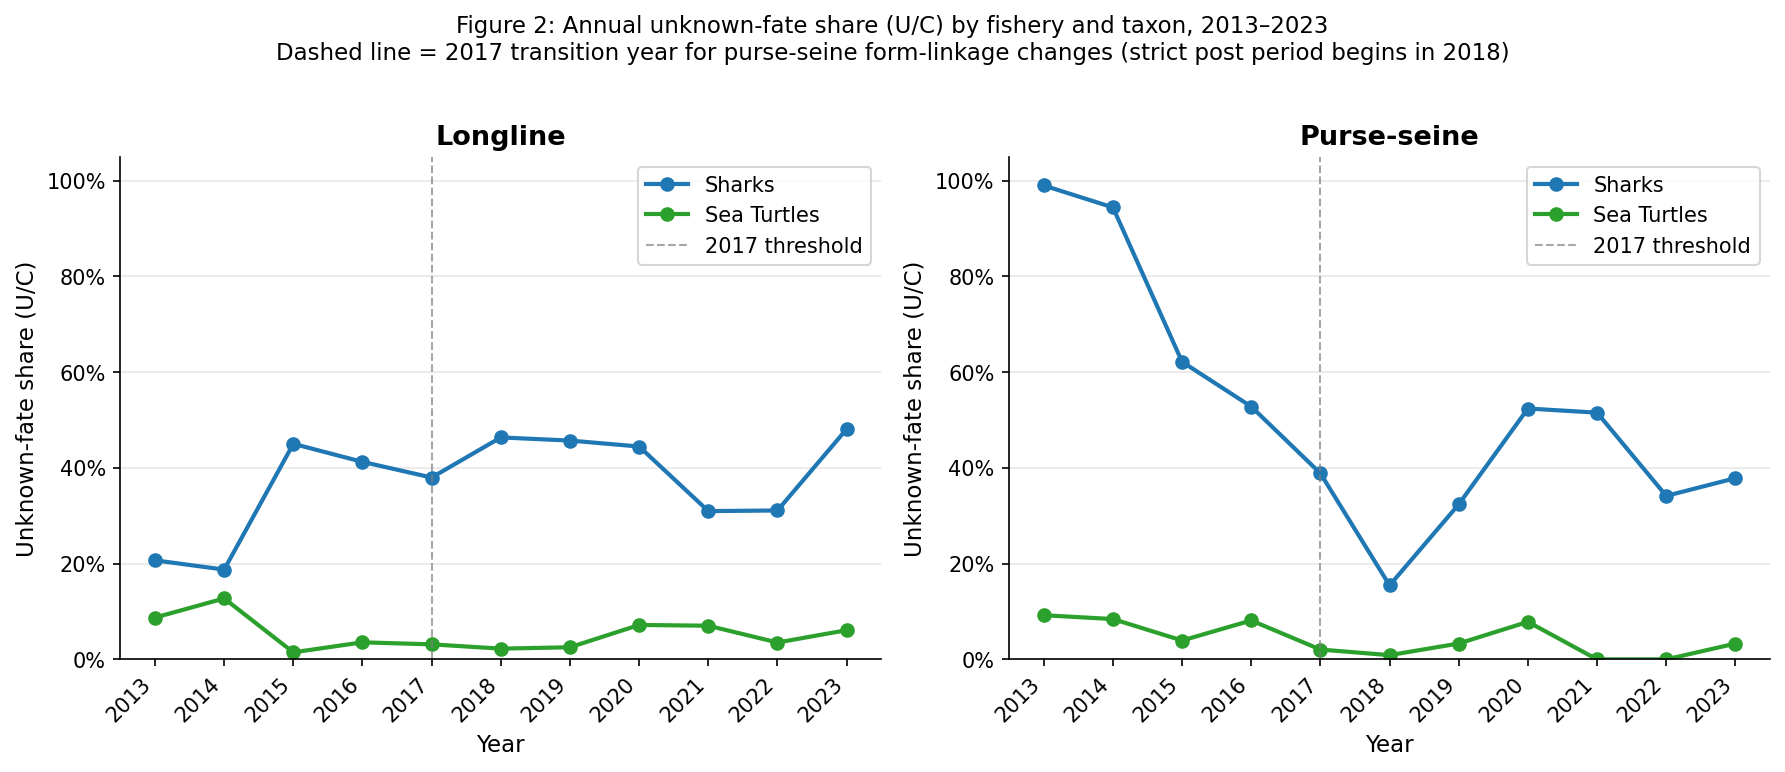

Saved: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/fig2_uf_share_over_time.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

fishery_panels = [('L', 'Longline', axes[0]), ('S', 'Purse-seine', axes[1])]
color_map = {'SHK': '#1f77b4', 'TTX': '#2ca02c'}
label_map = {'SHK': 'Sharks', 'TTX': 'Sea Turtles'}

for fishery_code, fishery_name, ax in fishery_panels:
    sub = strata_focal[strata_focal['fishery'] == fishery_code]
    for taxon_code in ['SHK', 'TTX']:
        tsub = sub[sub['taxon'] == taxon_code].sort_values('year')
        ax.plot(
            tsub['year'], tsub['UF_share'],
            marker='o', linewidth=2, markersize=6,
            color=color_map[taxon_code],
            label=label_map[taxon_code]
        )
    # 2017 transition reference line (implementation began mid-2017; strict post = 2018+)
    ax.axvline(x=2017, color='grey', linestyle='--', linewidth=1,
               alpha=0.7, label='2017 threshold')
    ax.set_title(fishery_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Unknown-fate share (U/C)', fontsize=11)
    ax.set_xticks(range(2013, 2024))
    ax.set_xticklabels(range(2013, 2024), rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Figure 2: Annual unknown-fate share (U/C) by fishery and taxon, 2013–2023\n'
    'Dashed line = 2017 transition year for purse-seine form-linkage changes (strict post period begins in 2018)',
    fontsize=11, y=1.02
)
plt.tight_layout()

# Save
fig2_path = output_path + 'fig2_uf_share_over_time.png'
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig2_path}")

- figure is diagnostic, not causal
- the vertical line marks a transition reference point, not proof of abrupt change

---
### CELL 13 — Figure: Shark vs turtle UF share comparison (Figure 4a draft)

**What:** Box/strip plot comparing the distribution of annual UF_share
for sharks vs turtles within each fishery.

**Why:** This is the visual equivalent of the shark/turtle contrast
that is central to the paper's narrative. The literature shows sharks
have much higher unknown-fate burden while turtles have lower but non-negligible burden.
Showing this contrast directly makes the case
that our method does not 'find bias everywhere' — it finds it where
the biology and monitoring system predict it.

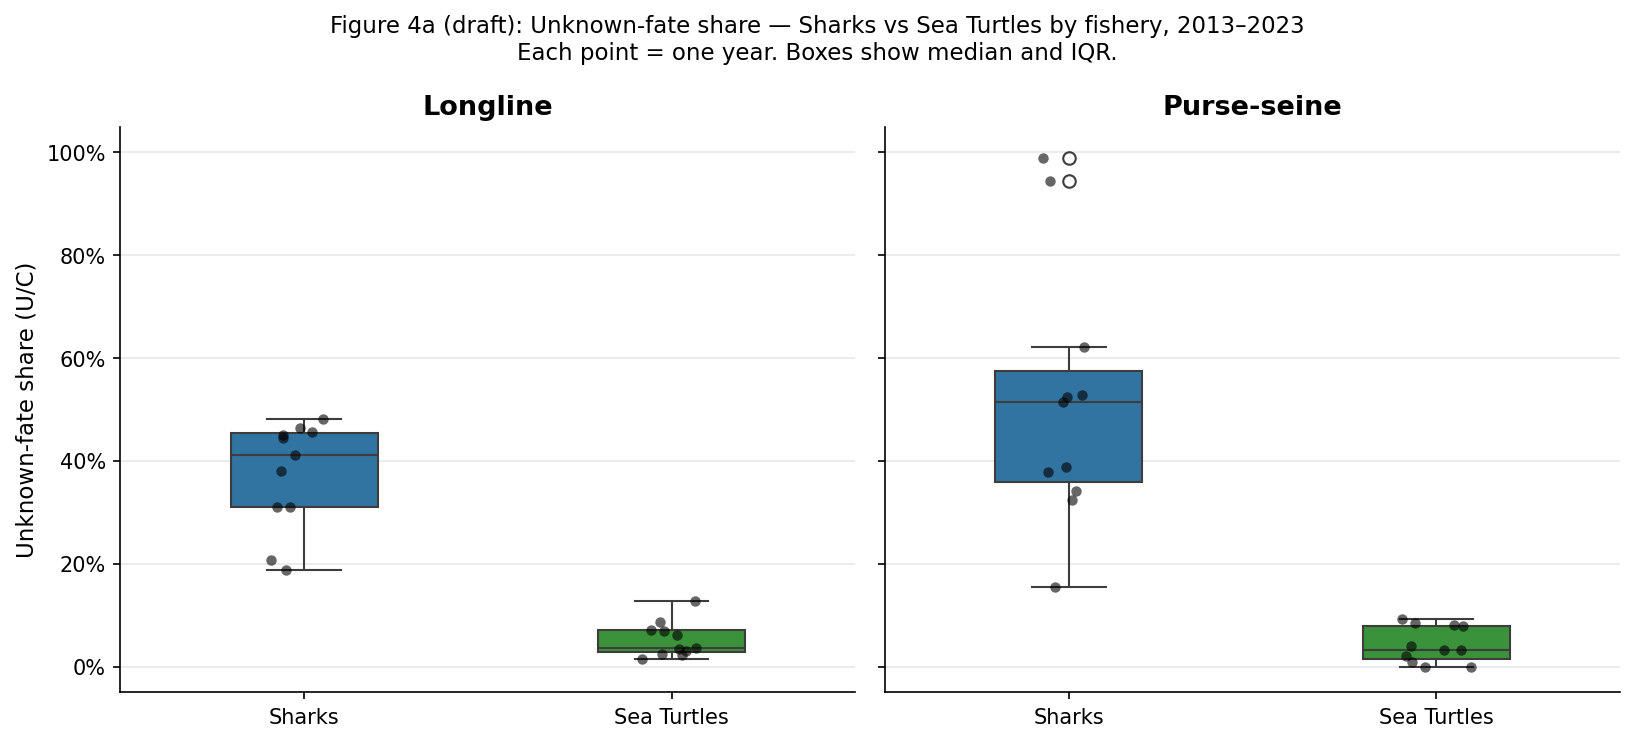

Saved: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/fig4a_shark_vs_turtle_uf_share.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

palette = {'Sharks': '#1f77b4', 'Sea Turtles': '#2ca02c'}

for ax, (fishery_code, fishery_name) in zip(axes, [('L', 'Longline'), ('S', 'Purse-seine')]):
    sub = strata_focal[strata_focal['fishery'] == fishery_code]
    sns.boxplot(
        data=sub, x='taxon_label', y='UF_share',
        palette=palette, width=0.4, ax=ax
    )
    sns.stripplot(
        data=sub, x='taxon_label', y='UF_share',
        color='black', size=5, alpha=0.6, jitter=True, ax=ax
    )
    ax.set_title(fishery_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Unknown-fate share (U/C)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Figure 4a (draft): Unknown-fate share — Sharks vs Sea Turtles by fishery, 2013–2023\n'
    'Each point = one year. Boxes show median and IQR.',
    fontsize=11
)
plt.tight_layout()

fig4a_path = output_path + 'fig4a_shark_vs_turtle_uf_share.png'
plt.savefig(fig4a_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig4a_path}")

- this figure compares burden distributions across years
- it is descriptive support for the later adjustment model, not the main inferential result

---
### CELL 14 — Save processed datasets for Notebook 2

**What:** Export the cleaned species-level dataframe and the aggregated
strata dataframe as CSVs to the shared output folder.

**Why:** All subsequent notebooks (2, 3, 4) load from these saved files
rather than re-running the raw import steps. This ensures full
reproducibility: if the raw WCPFC workbook is updated, only this
notebook needs to be re-run, and all downstream notebooks automatically
use the updated processed data.

In [20]:
# Species-level dataset (all taxa, all years)
species_out = output_path + 'NB1_species_level.csv'
df.to_csv(species_out, index=False)
print(f"Saved species-level data: {species_out}  ({len(df):,} rows)")

# Strata-level dataset (aggregated by fishery × taxon × year)
strata_out = output_path + 'NB1_strata.csv'
strata.to_csv(strata_out, index=False)
print(f"Saved strata data       : {strata_out}  ({len(strata)} rows)")

# Table 1 observer coverage
t1_out = output_path + 'NB1_observer_coverage.csv'
t1.to_csv(t1_out, index=False)
print(f"Saved observer coverage : {t1_out}")

# Diagnostic summary table (Table 1 of manuscript draft)
diag_out = output_path + 'NB1_table1_uf_summary.csv'
summary.to_csv(diag_out, index=False)
print(f"Saved diagnostic table  : {diag_out}")

print()
print("=" * 60)
print("Notebook 1 complete.")
print("Next: Notebook 2 — Transparent Mortality Metrics")
print("=" * 60)

Saved species-level data: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB1_species_level.csv  (1,110 rows)
Saved strata data       : /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB1_strata.csv  (82 rows)
Saved observer coverage : /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB1_observer_coverage.csv
Saved diagnostic table  : /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB1_table1_uf_summary.csv

Notebook 1 complete.
Next: Notebook 2 — Transparent Mortality Metrics


---
## End of Notebook 1

### Summary of what was produced

| Output file | Used in |
|---|
| `NB1_species_level.csv` | Notebook 2 (metrics), Notebook 3 (model) |
| `NB1_strata.csv` | All notebooks |
| `NB1_observer_coverage.csv` | Manuscript Table 1 |
| `NB1_table1_uf_summary.csv` | Manuscript Table 1 |
| `fig2_uf_share_over_time.png` | Manuscript Figure 2 |
| `fig4a_shark_vs_turtle_uf_share.png` | Manuscript Figure 4 (draft) |

### Key findings from Phase 2 diagnostics

- ✅ No U < 0 violations — data integrity confirmed
- Shark UF_share (longline): mean ~37%, rising to ~48% in 2023
- Shark UF_share (purse-seine): mean ~52%, with very high values before 2017
- Turtle UF_share: consistently low (~4–9%) — confirms contrast-taxon choice
- Pre/post-2017 PS pattern visible — consistent with WCPFC Note 6
- These findings directly support H1, H2, H3 and will appear in Results

### Paper mapping

| Paper section | Notebook 1 content |
|---|
| Methods — Data | Cells 3–7 (data source, variables, window) |
| Methods — Diagnostics | Cells 8–11 |
| Results — Table 1 | Cell 9 output |
| Results — Figure 2 | Cell 12 |
| Results — Figure 4 (partial) | Cell 13 |
| Sensitivity justification | Cell 11 (pre/post-2017 pattern) |

- NB1 now produces defensible downstream inputs:
cleaned species-level data
- annual strata with coverage context
annual strata with multiple 2017 break codings

## Notebook 1 Complete Summary: Data Ingestion, Stratum Construction & Quality Diagnostics

This notebook covered the critical initial phases of the WCPFC BDEP Bycatch Mortality Bias project:

### What We Did (Methodology)

**Phase 1: Data Ingestion & Stratum Construction**

1.  **Google Drive Mounting & Path Configuration (CELL 1):** Mounted Google Drive and defined consistent input/output paths for reproducibility across notebooks.
2.  **Library Setup (CELL 2):** Installed `openpyxl` and imported `pandas`, `numpy`, `matplotlib`, and `seaborn`. Defined a global plot style and a consistent color palette.
3.  **Workbook Inspection (CELL 3):** Reviewed sheet names (`Table 1`, `Table 2`, `Table 3`) and the first three rows of each to understand raw data structure and column headers.
4.  **Loading Table 1 (Observer Coverage) (CELL 4):**
    *   Loaded `Table 1`, extracted relevant columns, and filtered data to the 2013-2023 analysis window.
    *   **Derived Fishery-Specific Coverage Flags:** Calculated the 25th percentile, median, min, and max of observer coverage for each fishery (`L` and `S`). A `low_coverage_flag` was created for years falling below the 25th percentile *within their respective fishery*. This approach provides a contextual warning without arbitrary cross-fishery thresholds, offering a cleaner defense in review.
5.  **Loading Tables 2 & 3 (Bycatch Data) (CELL 5):** Loaded longline (`Table 2`) and purse-seine (`Table 3`) annual bycatch data. Standardized column names (e.g., 'Observed Captures' and 'Observed Interactions' both mapped to `C` for 'Captures/Interactions') to enable consistent cross-gear analysis.
6.  **Combine Tables, Filter, and Derive U (CELL 6):** Concatenated the longline and purse-seine data, filtered to the main analysis window (2013–2023), and ensured numerical column types. The core variable `U` (unknown fate count) was derived as `C - M - L` (Captures - Mortalities - Live Releases), and `UF_share` (U/C) was calculated. Human-readable labels were added for plots.
7.  **Build Annual Strata (CELL 7):** Aggregated species-level data to the primary analysis stratum: `fishery × taxon × year`. Re-derived stratum-level rates (`UF_share`, `nominal_mort`, `known_mort`). Merged the observer coverage context from Table 1 and coded 2017 transition flags for later sensitivity analysis.

**Phase 2: Data Quality Diagnostics**

1.  **Integrity Check: U ≥ 0 (CELL 8):** Verified that all derived `U` values were non-negative, confirming the internal consistency of the WCPPC data and the validity of our derived `U` variable.
2.  **Unknown-fate Burden Summary (CELL 9):** Calculated mean, median, min, max, and standard deviation of `UF_share` for each `fishery × taxon` combination across 2013–2023.
3.  **Annual Unknown-fate Share (CELL 10):** Displayed the year-by-year `UF_share` for focal taxa (Sharks and Sea Turtles) to identify temporal patterns.
4.  **Pre/post-2017 Comparison (CELL 11):** Performed a diagnostic comparison of mean `UF_share` for purse-seine sharks (and longline sharks as a control) before and after 2017, testing the hypothesis of a measurement-regime shift.
5.  **Figure 2: Unknown-fate share over time (CELL 12):** Generated a line plot visualizing annual `UF_share` for sharks and turtles by fishery, with a dashed line marking the 2017 transition.
6.  **Figure 4a: Shark vs turtle UF share comparison (CELL 13):** Produced a box/strip plot comparing the distribution of `UF_share` for sharks vs. sea turtles within each fishery.

**Data Export (CELL 14):** Exported the cleaned species-level dataframe, aggregated strata dataframe, observer coverage data, and the diagnostic summary table (Table 1 draft) as CSVs for use in subsequent notebooks.

### What We Found (Key Findings)

*   **Data Integrity:** All `U` values were confirmed to be ≥ 0, indicating the WCPFC public tables are arithmetically coherent and no rows required exclusion based on this check.
*   **Unknown-Fate Burden:**
    *   **Sharks (Longline):** Showed a mean `UF_share` of ~37%, with values rising to ~48% in 2023. Median was 41.2%.
    *   **Sharks (Purse-seine):** Had a higher mean `UF_share` of ~52%, characterized by very high values (up to 99%) before 2017, confirming a significant data gap in earlier years.
    *   **Sea Turtles:** Consistently exhibited a much lower `UF_share` (mean ~4–5% in both fisheries), validating their role as a contrast taxon.
*   **2017 Transition:** A significant drop in `UF_share` for purse-seine sharks was observed from 2017 onwards, consistent with WCPFC Note 6 regarding the resolution of the GEN-2/PS-3 form-linkage issue. Longline sharks, serving as a control, did not show such a sharp drop, further supporting the hypothesis of a measurement-regime shift in purse-seine data.

### Discussion

These diagnostic results are crucial for understanding the nature and magnitude of unknown fate bias in WCPFC bycatch data. The findings directly support several hypotheses: that sharks (especially purse-seine) carry the largest unknown-fate burden, that sea turtles serve as a good contrast due to lower burden, and that the pre/post-2017 change in purse-seine data is empirically detectable.

The approach of using a **fishery-specific lower-quartile flag** for observer coverage provides:
*   **A contextual warning flag:** It highlights years where coverage was unusually low *relative to that fishery's own historical patterns*, rather than against an arbitrary global threshold.
*   **No arbitrary cross-fishery threshold:** This is critical because longline and purse-seine operations have vastly different historical coverage rates and operational contexts, making a single, universal threshold scientifically unsound.
*   **A cleaner defense in review:** This method is more defensible to reviewers as it respects the inherent differences between fisheries while still flagging potential data quality concerns.

**Connection to the Paper:**

*   **Methods Section (Data):** Cells 3–7 (data sources, variable definitions, analysis window).
*   **Methods Section (Diagnostics):** Cells 8–11.
*   **Results Section (Table 1):** The summary table generated in CELL 9.
*   **Results Section (Figure 2):** The `UF_share` over time plot from CELL 12.
*   **Results Section (Figure 4a):** The shark vs. turtle comparison plot from CELL 13.
*   **Sensitivity Justification:** The pre/post-2017 pattern analysis in CELL 11 provides empirical justification for incorporating a `post2017` indicator in the Bayesian model and conducting sensitivity analyses.

This notebook successfully produced defensible downstream inputs, including cleaned species-level data, annual strata with observer coverage context, and annual strata with multiple 2017 break codings, ready for further analysis in Notebooks 2 and 3.

---

### Key Tables from Notebook 1

**Table 1 (draft): Unknown-fate share (U/C) by fishery × taxon, 2013–2023**

```
    Fishery          Taxon  Mean UF share  Median    Min    Max     SD
   Longline Marine Mammals          0.080   0.060  0.025  0.273  0.075
   Longline    Sea Turtles          0.053   0.036  0.015  0.127  0.034
   Longline       Seabirds          0.012   0.007  0.000  0.043  0.014
   Longline         Sharks          0.373   0.412  0.188  0.481  0.105
Purse-seine Marine Mammals          0.105   0.088  0.007  0.273  0.081
Purse-seine    Sea Turtles          0.043   0.033  0.000  0.092  0.035
Purse-seine       Seabirds          0.300   0.000  0.000  1.000  0.447
Purse-seine         Sharks          0.519   0.515  0.155  0.990  0.255
```

**Annual unknown-fate share (U/C) — Sharks and Turtles**

```
fishery_label    Longline        Purse-seine       
taxon_label   Sea Turtles Sharks Sea Turtles Sharks
year                                               
2013                0.087  0.207       0.092  0.990
2014                0.127  0.188       0.084  0.944
2015                0.015  0.450       0.039  0.621
2016                0.036  0.412       0.081  0.528
2017                0.031  0.380       0.021  0.388
2018                0.022  0.464       0.009  0.155
2019                0.025  0.457       0.033  0.324
2020                0.072  0.445       0.078  0.524
2021                0.070  0.310       0.000  0.515
2022                0.035  0.311       0.000  0.341
2023                0.061  0.481       0.033  0.378
```

**2017 break sensitivity check — shark unknown-fate share**

```
                   Series           Break definition Pre years Post years  Pre mean  Post mean  Post − Pre  2017 transition value
       Purse-seine sharks      2017 included in post 2013–2016  2017–2023     0.771      0.375      -0.396                  0.388
       Purse-seine sharks 2017 treated as transition 2013–2016  2018–2023     0.771      0.373      -0.398                  0.388
Longline sharks (control)      2017 included in post 2013–2016  2017–2023     0.314      0.407       0.092                  0.380
Longline sharks (control) 2017 treated as transition 2013–2016  2018–2023     0.314      0.411       0.097                  0.380
```